In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy

In [2]:
# data columns:
#     name
#     milogP (from https://www.molinspiration.com/cgi/properties)
#     current decay time constant (s) in washout experiments, AKA washout time constant
#     current decay time constant uncertainty (s)
#     R group name
#     R group logP (from pubchem)
#     new molecule name for paper
#     comments to the right are the sources cited by pubchem
data = [["GLPG1837", 1.76, 17.4,   4.2,    "pyrazole",            0.26, "ABBV-974"],  #HANSCH,C ET AL. (1995)
        ["fmrly C2", 0,    46.15,  2.04,   "isoamyl alcohol",     1.16, "CFTRi-C3"],  #Hansch, C., Leo, A., D. Hoekman. Exploring QSAR - Hydrophobic, Electronic, and Steric Constants. Washington, DC: American Chemical Society., 1995., p. 15
        ["JM97",     2.59, 56.5,   25.51,  "phenylethyl alcohol", 1.36, "JM97"],      #Hansch, C. and A. Leo. The Log P Database. Claremont, CA: Pomona College, 1987.
#        ["",         0,    19.9,   6.5,    "NBD+5-amino-pentan-1-ol", 1.6+-0.3, "NBD-CFTRi"], #need an actual computed logP; computed by XLogP3-AA (put in experimental column for plotting), based on https://pubchem.ncbi.nlm.nih.gov/compound/NBD-Cl and https://pubchem.ncbi.nlm.nih.gov/compound/5-Aminopentan-1-ol#section=Wikipedia
        ["JM112",    3.74, 243.02, 74.81,  "1-heptanol",          2.62, "CFTRi-C6"],  #Sangster J; Log KOW Databank. Sangster Res Lab. (1994)
        ["JM96",     5.76, 2166.5, 1079.9, "1-undecanol",         4.72, "CFTRi-C10"]  #Abraham MH et al; J Pharm Sci 83: 1085-100 (1994)
       ]

labels_wm = [d[0] for d in data]
labels_wm2 = [d[6] for d in data]
labels_r = [d[4] for d in data]

washout_time_constants = [d[2] for d in data]
washout_rates = [1/d[2] for d in data]

washout_time_constants_err = [d[3] for d in data]
#washout_rates_err = [1/d[3] for d in data]

#predicted membrane-water partitioning time constants and rates using eq. 34.3 with m=1 chosen arbitrarily
r_group_logp_time_constants  = [10**(d[5]/2) for d in data]
r_group_logp_rates = [10**(-d[5]/2) for d in data]

whole_molecule_milogp_time_constants  = [10**(d[1]/2) for d in data]
whole_molecule_milogp_rates  = [10**(-d[1]/2) for d in data]

mean proportionality constant = 11.64034569886673


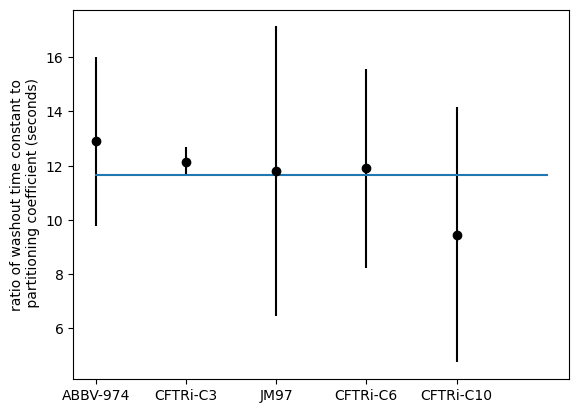

In [3]:
#calculate the value of the constant m from the appendix
time_constant_ratios = [d[2]*10**(-d[5]/2) for d in data]
#calculate the standard deviation of m assuming uncertainty in the logP values is negligible by comparison
time_constant_ratio_errors = [d[3]*10**(-d[5]/2) for d in data]
#estimate the value of m as the mean of the values calculated from individual data points
constant_est = np.mean(time_constant_ratios)

x_pos = [d for d in range(len(data))]

#plot all estimated m values with the mean as a horizontal line
plt.errorbar(x=x_pos, y=time_constant_ratios, yerr = time_constant_ratio_errors, linestyle="none", marker="o", color="black")

plt.plot([0,5],[constant_est, constant_est], color="C0")

#plt.ylim(0,20)
plt.ylabel("ratio of washout time constant to\n partitioning coefficient (seconds)")
plt.xticks(x_pos,[d[6] for d in data])
print(f"mean proportionality constant = {constant_est}")
#plt.ylim(10,14)

In [4]:
print(time_constant_ratios)
print(time_constant_ratio_errors)
print(time_constant_ratios[2]-time_constant_ratio_errors[2])

[12.898798198635964, 12.138686782597187, 11.80452313932532, 11.902604868291979, 9.457115505483198]
[3.1135030134638537, 0.536574670346658, 5.329794429808654, 3.664035347695346, 4.713934472361554]
6.474728709516667


In [5]:

#Notes:
# the variables x_rates, y_rates, and y_rates_err are actually used for time constants instead
# if statements pertaining to xticks are used to switch between main and inset plot formatting but this is not a very elegant code structure

def plot_rate_relations(x_rates, y_rates, y_rates_err, constant_est,
                        xlim, ylim, xticks, yticks, xlabel, ylabel, 
                        pointlabels, labelspacing, markersize, 
                        plottitle, figsize, fontsize, linewidth, axwidth, 
                        calculate_raw_rsquared = False,
                        include_nonzero_intercept_fit = False):
    
    #plot data
    fig, ax = plt.subplots(figsize=figsize)

    #for axis thickness details see https://stackoverflow.com/questions/2553521/setting-axes-linewidth-without-changing-the-rcparams-global-dict
    # change all spines
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(axwidth)
    
    # increase tick width
    ax.tick_params(width=axwidth)
    #plot ticks
    plt.xticks(xticks)
    plt.yticks(yticks)
    
    #plot data
    plt.errorbar(x_rates, y_rates, yerr = y_rates_err, color="black", marker="o", markersize=markersize, linestyle="none", linewidth=linewidth, zorder=999)

    #plot labels
    for i, txt in enumerate(pointlabels):
        ax.annotate(txt, (x_rates[i]+labelspacing, y_rates[i]), fontsize=fontsize)
    
    plt.xlabel(xlabel, fontsize=fontsize)
    plt.ylabel(ylabel, fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    #plot range
    plt.xlim(xlim)
    plt.ylim(ylim)
        

    #plot best fit line, extending to the intercept at 0,0, using the estimate of the slope m calculated in the previous cell
    predicted_values_0int = constant_est*np.array([0]+x_rates)
    
    total_sum_of_squares = sum([(yr-np.mean(y_rates))**2 for yr in y_rates])
    residuals = sum([(yr-xr*constant_est)**2 for xr, yr in zip(x_rates, y_rates)])
    r_squared = 1-residuals/total_sum_of_squares
    print(f"r-squared-for-ratio-fit = {r_squared}")
    
    plt.plot([0]+x_rates, predicted_values_0int, linewidth=linewidth)


    if calculate_raw_rsquared:
        #linear fit with intercepts fixed at 0,0 to match the functional form of eq. 34
        #ignore the warning thrown here, which originates somewhere within linalg.lstsq and is not fixable by adjusting the parameters here
        slope_direct, residuals_direct, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)
        
        #calculate the r^2 value from the residuals
        r_squared_direct = 1-residuals_direct[0]/total_sum_of_squares
        print(f"r-squared-for-direct-fit = {r_squared_direct}")
    
    if include_nonzero_intercept_fit:
        #linear fit including a nonzero intercept
        # this fit finds that the optimal intercept is nearly 0 as predicted by eq. 34.
        
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x_rates, y_rates)
        print(slope, intercept, r_value, p_value, std_err)
        
        predicted_values = slope*np.array(x_rates) + intercept*np.ones(len(x_rates))
        plt.plot(x_rates, predicted_values, linestyle="dashed")
    
        print(intercept/np.mean(x_rates))
    
    if plottitle != "":
        plt.savefig(plottitle+".svg", bbox_inches="tight", format='svg') 

    plt.show()
    

In [6]:
#shared parameters for inset and non-inset plots and base numerical values
x_rates = r_group_logp_time_constants
y_rates = washout_time_constants
y_rates_error = washout_time_constants_err

pointlabels = labels_wm2
base_fontsize = 14
base_axwidth = 1


r-squared-for-ratio-fit = 0.9280801056318622


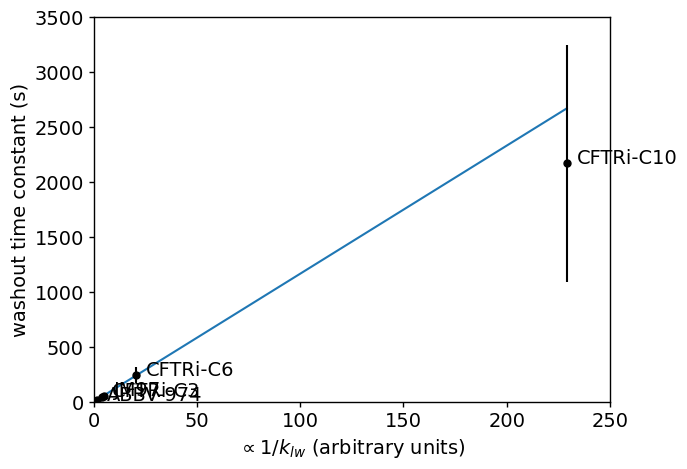

In [7]:
#main plot

xlabel_main = "$\propto 1/k_{lw}$ (arbitrary units)" #; time
ylabel_main = "washout time constant (s)"
labelspacing_main = 5
plottitle_main = "r_logp_time_constant_vs_washout_time_constant_rev_c3"

axwidth_main = 1
fontsize_main = 14
markersize_main = 5
linewidth_main = 1.5

xlim_main = (0,250)
ylim_main = (0,3500)
xticks_main = None
yticks_main = None
figsize_main = (6.66,5)

plot_rate_relations(x_rates, y_rates, y_rates_error, constant_est,
                        xlim_main, ylim_main, xticks_main, yticks_main, xlabel_main, ylabel_main, 
                        pointlabels, labelspacing_main, markersize_main, 
                        plottitle_main, figsize_main, fontsize_main, linewidth_main, axwidth_main, 
                        calculate_raw_rsquared = False,
                        include_nonzero_intercept_fit = False)


r-squared-for-ratio-fit = 0.9280801056318622


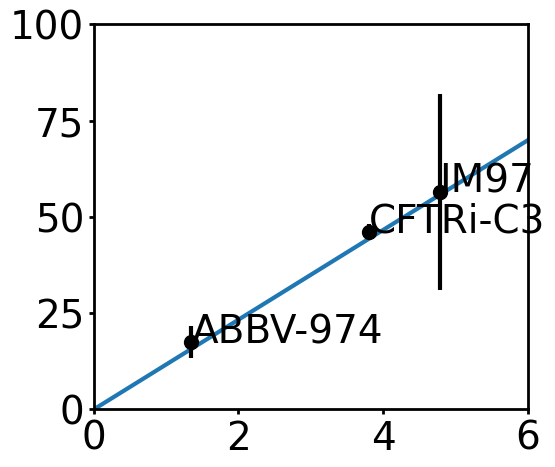

In [8]:
#inset plot

xlabel_inset = ""
ylabel_inset = ""
labelspacing_inset = 0
plottitle_inset = "r_logp_time_constant_vs_washout_time_constant_inset_2points_rev_c3"

scalefactor = 2
axwidth_inset = axwidth_main*scalefactor
fontsize_inset = fontsize_main*scalefactor
markersize_inset = markersize=markersize_main*scalefactor
linewidth_inset = linewidth_main*scalefactor

xlim_inset = (0,6)
ylim_inset = (0,100)
xticks_inset = [0,2,4,6]
yticks_inset = [0,25,50,75,100]
figsize_inset = (figsize_main[0]*(ylim_main[1]/xlim_main[1])/(ylim_inset[1]/xlim_inset[1]), figsize_main[1])

plot_rate_relations(x_rates, y_rates, y_rates_error, constant_est,
                        xlim_inset, ylim_inset, xticks_inset, yticks_inset, xlabel_inset, ylabel_inset, 
                        pointlabels, labelspacing_inset, markersize_inset, 
                        plottitle_inset, figsize_inset, fontsize_inset, linewidth_inset, axwidth_inset, 
                        calculate_raw_rsquared = False,
                        include_nonzero_intercept_fit = False)


In [9]:
####################################################################################################
#                                     OLD CODE BELOW
####################################################################################################

In [10]:

#Notes:
# the variables x_rates, y_rates, and y_rates_err are actually used for time constants instead
# if statements pertaining to xticks are used to switch between main and inset plot formatting but this is not a very elegant code structure

def plot_rate_relations(x_rates, y_rates, y_rates_err, xlabel, ylabel, pointlabels, labelspacing, xlim, ylim, xticks, yticks, plottitle, fs, axwidth=1, include_nonzero_intercept_fit = False):
    
    #plot data
    if xticks != ():
        fig, ax = plt.subplots(figsize=(6.66*21/25,5))
    else:
        fig, ax = plt.subplots(figsize=(6.66,5))

    #for axis thickness details see https://stackoverflow.com/questions/2553521/setting-axes-linewidth-without-changing-the-rcparams-global-dict
    #axwidth = 4
    # change all spines
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(axwidth)
    
    # increase tick width
    ax.tick_params(width=axwidth)
    
    if y_rates_err == []:
        plt.scatter(x_rates, y_rates, color="black")
    else:
        plottitle += "_yerr"
        if xticks != ():
            #plt.errorbar(x_rates[1:], y_rates[1:], yerr = y_rates_err[1:], color="black", marker="o", markersize=4*axwidth, linestyle="none", linewidth=1.7*axwidth, zorder=999)
            #plt.errorbar([x_rates[0]], [y_rates[0]], yerr = [y_rates_err[0]], color="black", marker="o", markersize=4*axwidth, linestyle="none", linewidth=1.7*axwidth, zorder=999)
            plt.errorbar(x_rates, y_rates, yerr = y_rates_err, color="black", marker="o", markersize=4*axwidth, linestyle="none", linewidth=1.7*axwidth, zorder=999)
        else:
            plt.errorbar(x_rates, y_rates, yerr = y_rates_err, color="black", marker="o", markersize=5, linestyle="none", zorder=999)

    #plot labels
    for i, txt in enumerate(pointlabels):
        ax.annotate(txt, (x_rates[i]+labelspacing, y_rates[i]), fontsize=fs)
    
    plt.xlabel(xlabel, fontsize=fs)
    plt.ylabel(ylabel, fontsize=fs)
    plt.xticks(fontsize=fs)
    plt.yticks(fontsize=fs)

    #plot range
    if xlim != ():
        plt.xlim(xlim)
    if ylim != ():
        plt.ylim(ylim)
    
    #plot ticks
    if xticks != ():
        plt.xticks(xticks)
    if yticks != ():
        plt.yticks(yticks)
        
    #linear fit with intercepts fixed at 0,0 to match the functional form of eq. 34
    #ignore the warning thrown here, which originates somewhere within linalg.lstsq and is not fixable by adjusting the parameters here
    slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)
    
    #calculate the r^2 value from the residuals
    total_sum_of_squares = sum([(yr-np.mean(y_rates))**2 for yr in y_rates])
    r_squared_0int = 1-residuals[0]/total_sum_of_squares
    print(f"r-squared = {r_squared_0int}")
    
    #plot best fit line, extending to the intercept at 0,0
    #predicted_values_0int = slope_0int*np.array([0]+x_rates)
    predicted_values_0int = constant_est*np.array([0]+x_rates) #ratio based

    residuals_v2 = sum([(yr-xr*constant_est)**2 for xr, yr in zip(x_rates, y_rates)])
    r_squared_v2 = 1-residuals_v2/total_sum_of_squares
    print(f"r-squared-v2 = {r_squared_v2}")
    
    if xticks != ():
        plt.plot([0]+x_rates, predicted_values_0int, linewidth=1.7*axwidth)
    else:
        plt.plot([0]+x_rates, predicted_values_0int)
    
    if include_nonzero_intercept_fit:
        #linear fit including a nonzero intercept
        # this fit finds that the optimal intercept is nearly 0 as predicted by eq. 34.
        
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x_rates, y_rates)
        print(slope, intercept, r_value, p_value, std_err)
        
        predicted_values = slope*np.array(x_rates) + intercept*np.ones(len(x_rates))
        plt.plot(x_rates, predicted_values, linestyle="dashed")
    
        print(intercept/np.mean(x_rates))
    
    if plottitle != "":
        plt.savefig(plottitle+".svg", bbox_inches="tight", format='svg') 

    plt.show()

r-squared = 0.9992177567492391
r-squared-v2 = 0.9280801056318622


/var/folders/xr/fxj70vfj0bv2kxlwy2bbtz880000gn/T/ipykernel_43718/2834598261.py:56: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)


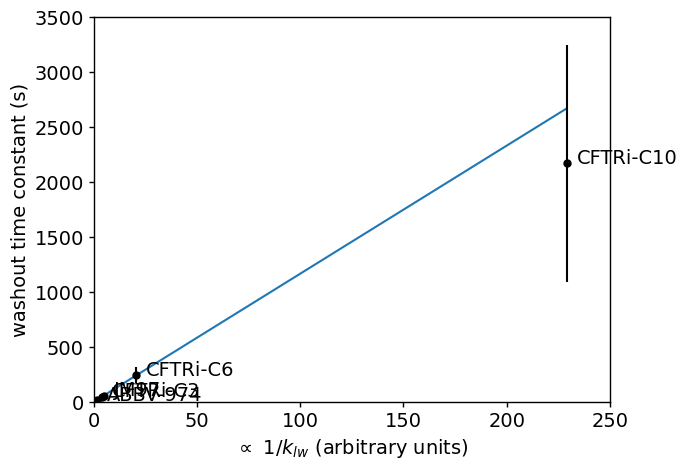

In [11]:
x_rates = r_group_logp_time_constants
y_rates = washout_time_constants
y_rates_error = washout_time_constants_err
xlabel = "$\propto$ 1/$k_{lw}$ (arbitrary units)"
ylabel = "washout time constant (s)"
pointlabels = labels_wm2
label_spacing = 5
plottitle = "r_logp_time_constant_vs_washout_time_constant"
fs = 14
xlim = (0,250)
ylim = (0,3500)
xticks = ()
yticks = ()

plot_rate_relations(x_rates, y_rates, y_rates_error, xlabel, ylabel, pointlabels, label_spacing, xlim, ylim, xticks, yticks, plottitle, fs)

r-squared = 0.9992177567492391
r-squared-v2 = 0.9280801056318622


/var/folders/xr/fxj70vfj0bv2kxlwy2bbtz880000gn/T/ipykernel_43718/2834598261.py:56: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)


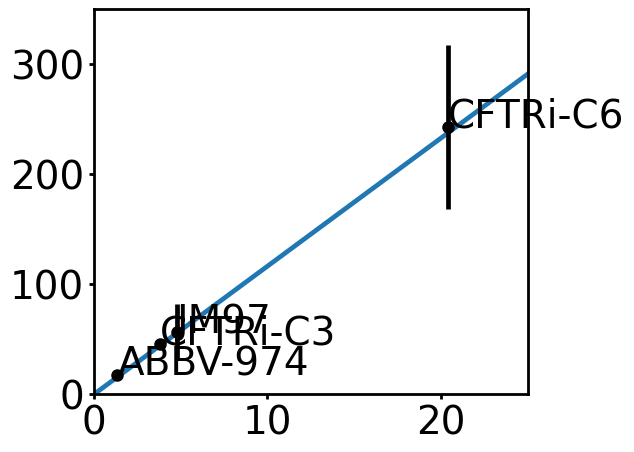

In [12]:
x_rates = r_group_logp_time_constants
y_rates = washout_time_constants
y_rates_error = washout_time_constants_err
xlabel = "" #"Predicted 1/$k_{lw}$ (arbitrary units; time)"
ylabel = "" #"washout time constant (s)"
pointlabels = labels_wm2
label_spacing = 0
plottitle = "r_logp_time_constant_vs_washout_time_constant_inset"
scalefactor = 2
fs = 14*scalefactor
xlim = (0,25)
ylim = (0,350)
xticks = [0,10,20]
yticks = [0,100,200,300]

plot_rate_relations(x_rates, y_rates, y_rates_error, xlabel, ylabel, pointlabels, label_spacing, xlim, ylim, xticks, yticks, plottitle, fs, scalefactor)

/var/folders/xr/fxj70vfj0bv2kxlwy2bbtz880000gn/T/ipykernel_43718/2834598261.py:56: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)


r-squared = 0.9992177567492391
r-squared-v2 = 0.9280801056318622


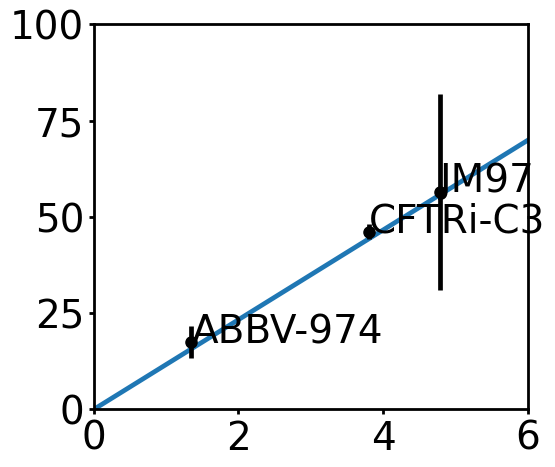

In [13]:
x_rates = r_group_logp_time_constants
y_rates = washout_time_constants
y_rates_error = washout_time_constants_err
xlabel = "" #"Predicted 1/$k_{lw}$ (arbitrary units; time)"
ylabel = "" #"washout time constant (s)"
pointlabels = labels_wm2
label_spacing = 0
plottitle = "r_logp_time_constant_vs_washout_time_constant_inset_2points"
scalefactor = 2
fs = 14*scalefactor
xlim = (0,6)
ylim = (0,100)
xticks = [0,2,4,6]
yticks = [0,25,50,75,100]

plot_rate_relations(x_rates, y_rates, y_rates_error, xlabel, ylabel, pointlabels, label_spacing, xlim, ylim, xticks, yticks, plottitle, fs, scalefactor)

/var/folders/xr/fxj70vfj0bv2kxlwy2bbtz880000gn/T/ipykernel_43718/2834598261.py:56: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(x_rates)[:,np.newaxis], y_rates)


r-squared = 0.9992177567492391
r-squared-v2 = 0.9280801056318622


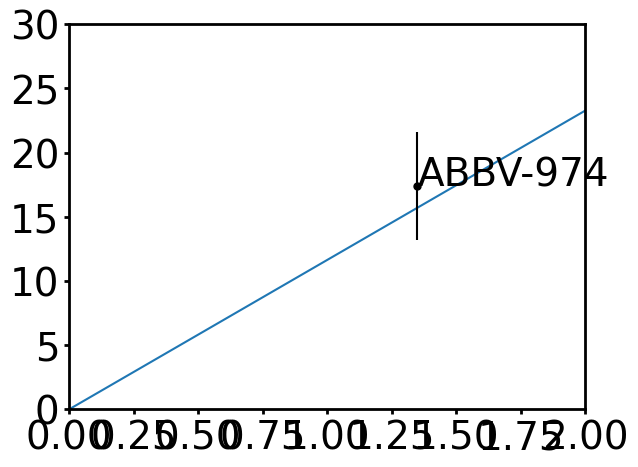

In [14]:
x_rates = r_group_logp_time_constants
y_rates = washout_time_constants
y_rates_error = washout_time_constants_err
xlabel = "" #"Predicted 1/$k_{lw}$ (arbitrary units; time)"
ylabel = "" #"washout time constant (s)"
pointlabels = labels_wm2
label_spacing = 0
plottitle = "r_logp_time_constant_vs_washout_time_constant_inset"
scalefactor = 2
fs = 14*scalefactor
xlim = (0,2)
ylim = (0,30)
xticks=()
yticks=()

#xticks = [0,10,20]
#yticks = [0,100,200,300]

plot_rate_relations(x_rates, y_rates, y_rates_error, xlabel, ylabel, pointlabels, label_spacing, xlim, ylim, xticks, yticks, plottitle, fs, scalefactor)

In [15]:
x_rates = r_group_logp_rates
y_rates = washout_rates
xlabel = "$k_{lw}$ predicted from R group logP\n(arb. units; inverse time)"
ylabel = "washout rate (1/s)"
pointlabels = labels_r
labelspacing = 0.01
plottitle = "r_logp_rate_vs_washout_rate"
xlim = (0,0.8)
ylim = (0,0.06)

plot_rate_relations(x_rates, y_rates, [], xlabel, ylabel, pointlabels, labelspacing, xlim, ylim, (),(), plottitle)

TypeError: plot_rate_relations() missing 1 required positional argument: 'fs'

In [ ]:
x_rates = whole_molecule_milogp_rates
y_rates = washout_rates
xlabel = "Membrane unbinding rate predicted from whole molecule milogP\n(arb. units; inverse time)"
ylabel = "washout rate (1/s)"
pointlabels = labels_wm
labelspacing = 0.002
plottitle = "wm_milogp_rate_vs_washout_rate"
xlim = (0,0.16)
ylim = (0,0.06)
plot_rate_relations(x_rates, y_rates, xlabel, ylabel, pointlabels, labelspacing, xlim, ylim, plottitle)

In [ ]:
x_rates = whole_molecule_milogp_time_constants
y_rates = washout_time_constants
xlabel = "Membrane unbinding time constant predicted\nfrom whole molecule milogP (arb. units; time)"
ylabel = "washout time constant (s)"
pointlabels = labels_wm
label_spacing = 20
plottitle = "wm_milogp_time_constant_vs_washout_time_constant"
xlim = (0,900)
ylim = (0,2250)
plot_rate_relations(x_rates, y_rates, xlabel, ylabel, pointlabels, label_spacing, xlim, ylim, plottitle)

In [ ]:
testxdata = [1,2,3,4,5]
testydata = [0.5,1.1,1.4,2,2.7]
plt.figure(figsize=(1,1))
plt.plot(testxdata,testydata)
plt.xlabel("test\ntest\ntest")